In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchmetrics
import torchvision
import torchvision.transforms.v2 as T
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Dataset
from scipy.spatial.transform import Rotation
from sklearn.manifold import TSNE
from collections import namedtuple
from diffusers import AutoPipelineForText2Image

device = 'cuda'

/home/damian/New Folder/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.


In [2]:
def eval_model(model, metric, valid_loader):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in valid_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            if isinstance(y_pred, tuple):
                y_pred = y_pred.output
            metric.update(y_pred, y_batch)
            
    return metric.compute()

def train_model(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs, 
                factor=0.5, patience=2, epoch_callback=None, temperature_decrease=False):
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', factor, patience)
    history = {'train_loss':[], 'train_metrics':[], 'valid_metrics':[]}
    
    for epoch in range(n_epochs):
        total_loss = 0.0
        model.train()
        metric.reset()
        if epoch_callback is not None:
            epoch_callback(model, epoch)
            
        if temperature_decrease == True:
            model.temperature = 1 - 0.7 * (epoch/n_epochs)
            
        for index, (X_batch, y_batch) in enumerate(train_loader):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
            
            if isinstance(y_pred, tuple):
                y_pred = y_pred.output
            metric.update(y_pred, y_batch)
            train_metric = metric.compute().item()
            print(f'\rBatch: {index + 1}/{len(train_loader)}', end="")
            print(f', loss={total_loss/(index+1):.3f}', end="")
            print(f', {train_metric=:.2f}', end="")
            
        history['train_loss'].append(total_loss/len(train_loader))
        history['train_metrics'].append(train_metric)
        val_metric = eval_model(model, metric, valid_loader)
        history['valid_metrics'].append(val_metric)
        
        scheduler.step(val_metric)
        print(f'\rEpoch: {epoch+1}/{n_epochs}\tTrain loss: {history["train_loss"][-1]:.3f}\tTrain metrics: {history['train_metrics'][-1]:.3f}\tValid metrics: {history['valid_metrics'][-1]:.3f}')
    
    return history

In [3]:
def generate_data(m, seed=52):
    X = np.zeros((m, 3))
    rng = np.random.default_rng(seed)
    angles = (rng.random(m)**3 + 0.5) * 2 * np.pi
    X[:, 0], X[:, 1] = np.cos(angles), np.sin(angles) * 0.5
    X += 0.37 * rng.standard_normal((m, 3))
    X = Rotation.from_rotvec([np.pi / 29, -np.pi / 19, np.pi / 4]).apply(X)
    X += [0.23, 0, 0.23]
    return torch.from_numpy(X.astype(np.float32))

In [10]:
X_train = generate_data(60)
X_valid = generate_data(500)

X_train_loader = DataLoader(TensorDataset(X_train, X_train), batch_size=32, shuffle=True)
X_valid_loader = DataLoader(TensorDataset(X_valid, X_valid), batch_size=32)

In [17]:
encoder = nn.Linear(3, 2)
decoder = nn.Linear(2, 3)
autoencoder = nn.Sequential(encoder, decoder).to(device)

optimizer = torch.optim.NAdam(autoencoder.parameters(), lr=0.2)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train_model(autoencoder, optimizer, mse, rmse, X_train_loader, X_valid_loader, 50)

Epoch: 1/50	Train loss: 0.344	Train metrics: 0.589	Valid metrics: 0.545
Epoch: 2/50	Train loss: 0.204	Train metrics: 0.452	Valid metrics: 0.451
Epoch: 3/50	Train loss: 0.136	Train metrics: 0.370	Valid metrics: 0.432
Epoch: 4/50	Train loss: 0.149	Train metrics: 0.384	Valid metrics: 0.418
Epoch: 5/50	Train loss: 0.107	Train metrics: 0.330	Valid metrics: 0.315
Epoch: 6/50	Train loss: 0.069	Train metrics: 0.262	Valid metrics: 0.291
Epoch: 7/50	Train loss: 0.059	Train metrics: 0.243	Valid metrics: 0.266
Epoch: 8/50	Train loss: 0.053	Train metrics: 0.232	Valid metrics: 0.260
Epoch: 9/50	Train loss: 0.052	Train metrics: 0.228	Valid metrics: 0.255
Epoch: 10/50	Train loss: 0.051	Train metrics: 0.227	Valid metrics: 0.253
Epoch: 11/50	Train loss: 0.050	Train metrics: 0.224	Valid metrics: 0.252
Epoch: 12/50	Train loss: 0.050	Train metrics: 0.223	Valid metrics: 0.250
Epoch: 13/50	Train loss: 0.051	Train metrics: 0.222	Valid metrics: 0.250
Epoch: 14/50	Train loss: 0.049	Train metrics: 0.222	Valid me

## stacked autoencoders

In [2]:
encoder = nn.Sequential(nn.Flatten(), nn.Linear(1*28*28, 128), nn.ReLU(), nn.Linear(128, 32), nn.ReLU())
decoder = nn.Sequential(nn.Linear(32, 128), nn.ReLU(), nn.Linear(128, 1*28*28), nn.Sigmoid(), nn.Unflatten(dim=1, unflattened_size=(1, 28, 28)))
stacked_autoencoder = nn.Sequential(encoder, decoder).to(device)

In [3]:
ToTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])
fashion_dataset = torchvision.datasets.FashionMNIST(root='/home/damian/test/ch10/datasets', train=True, transform=ToTensor)

fashion_train, fashion_valid = torch.utils.data.random_split(fashion_dataset, [55000, 5000])

In [4]:
fashion_valid_set = []
for el in fashion_valid:
    fashion_valid_set.append(torch.tensor(el[0], dtype=torch.float32))
fashion_valid_set = torch.stack(fashion_valid_set)

fashion_train_set = []
for el in fashion_train:
    fashion_train_set.append(torch.tensor(el[0], dtype=torch.float32))
fashion_train_set = torch.stack(fashion_train_set)

fashion_train_loader = DataLoader(TensorDataset(fashion_train_set, fashion_train_set), batch_size=32, shuffle=True)
fashion_valid_loader = DataLoader(TensorDataset(fashion_valid_set, fashion_valid_set), batch_size=32)

/tmp/ipykernel_5367/860554460.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fashion_valid_set.append(torch.tensor(el[0], dtype=torch.float32))
/tmp/ipykernel_5367/860554460.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fashion_train_set.append(torch.tensor(el[0], dtype=torch.float32))


In [7]:
optimizer = torch.optim.NAdam(stacked_autoencoder.parameters(), lr=0.01)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)

history = train_model(stacked_autoencoder, optimizer, mse, rmse, fashion_train_loader, fashion_valid_loader, 20)

Epoch: 1/20	Train loss: 0.025	Train metrics: 0.159	Valid metrics: 0.144
Epoch: 2/20	Train loss: 0.019	Train metrics: 0.139	Valid metrics: 0.136
Epoch: 3/20	Train loss: 0.018	Train metrics: 0.135	Valid metrics: 0.132
Epoch: 4/20	Train loss: 0.018	Train metrics: 0.133	Valid metrics: 0.144
Epoch: 5/20	Train loss: 0.016	Train metrics: 0.125	Valid metrics: 0.124
Epoch: 6/20	Train loss: 0.015	Train metrics: 0.124	Valid metrics: 0.124
Epoch: 7/20	Train loss: 0.015	Train metrics: 0.123	Valid metrics: 0.123
Epoch: 8/20	Train loss: 0.014	Train metrics: 0.119	Valid metrics: 0.119
Epoch: 9/20	Train loss: 0.014	Train metrics: 0.119	Valid metrics: 0.119
Epoch: 10/20	Train loss: 0.014	Train metrics: 0.118	Valid metrics: 0.118
Epoch: 11/20	Train loss: 0.014	Train metrics: 0.117	Valid metrics: 0.117
Epoch: 12/20	Train loss: 0.014	Train metrics: 0.116	Valid metrics: 0.117
Epoch: 13/20	Train loss: 0.014	Train metrics: 0.116	Valid metrics: 0.117
Epoch: 14/20	Train loss: 0.013	Train metrics: 0.115	Valid me

In [2]:
def plot_image(image):
    plt.imshow(image.permute(1, 2, 0).cpu(), cmap='binary')
    plt.axis('off')
    
def plot_reconstructions(model, images, n_images=5, ready_images=False):
    if not ready_images:
        images = images[:n_images]
        with torch.no_grad():
            y_pred = model(images.to(device))
            
        if isinstance(y_pred, tuple):
            y_pred = y_pred.output
        
    fig = plt.figure(figsize=(len(images)*1.5, 3))
    for idx in range(len(images)):
        plt.subplot(2, len(images), 1 + idx)
        plot_image(images[idx])
        if not ready_images:
            plt.subplot(2, len(images), 1+len(images)+idx)
            plot_image(y_pred[idx])


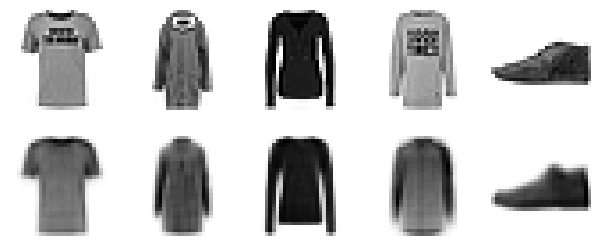

In [ ]:
X_valid = fashion_valid_set[:10]
plot_reconstructions(stacked_autoencoder, X_valid)
plt.show()

anomaly detection using autoencoder (terrible reconstructions, big MSE loss proof)

/tmp/ipykernel_6136/3783836479.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  numbers_set.append(torch.tensor(el[0], dtype=torch.float32))


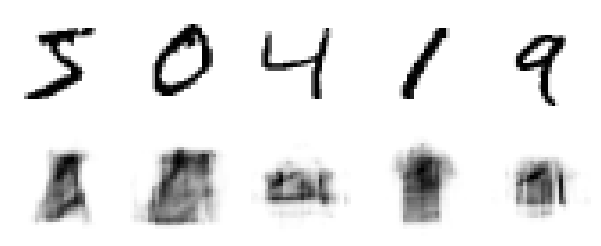

In [79]:
numbers_dataset = torchvision.datasets.MNIST(root='/home/damian/test/ch12/datasets', train=True, transform=ToTensor)

numbers_set = []
counter = 0
for el in numbers_dataset:
    numbers_set.append(torch.tensor(el[0], dtype=torch.float32))
    counter += 1
    if counter == 10:
        break
    
numbers_set = torch.stack(numbers_set)

plot_reconstructions(stacked_autoencoder, numbers_set)
plt.show()

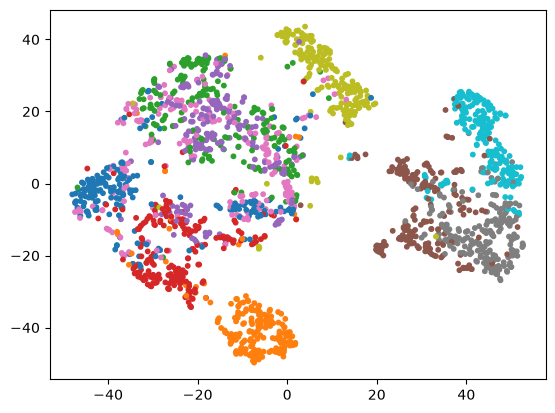

In [9]:
y_valid = []
counter = 0
X_valid = fashion_valid_set[:2000]

for el in fashion_valid:
    y_valid.append(torch.tensor(el[1], dtype=torch.float32))
    counter += 1
    if counter == 2000:
        break

with torch.no_grad():
    compressed_images = encoder(X_valid.to(device))
    
tsne = TSNE(init='pca', learning_rate='auto', random_state=52)
X_valid_2d = tsne.fit_transform(compressed_images.cpu())

plt.scatter(X_valid_2d[:, 0], X_valid_2d[:, 1], c=y_valid, s=10, cmap='tab10')
plt.show()

### Tying weigths

In [3]:
class TiedAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Linear(28*28, 128)
        self.enc2 = nn.Linear(128, 32)
        self.dec_b1 = nn.Parameter(torch.zeros(128))
        self.dec_b2 = nn.Parameter(torch.zeros(28*28))
        
    def encode(self, X):
        Z = X.view(-1, 28*28)
        Z = F.relu(self.enc1(Z))
        return F.relu(self.enc2(Z))
    
    def decode(self, Z):
        Z = F.relu(F.linear(Z, self.enc2.weight.T, self.dec_b1))
        Z = F.relu(F.linear(Z, self.enc1.weight.T, self.dec_b2))
        return Z.view(-1, 1, 28, 28)
    
    def forward(self, X):
        return self.decode(self.encode(X))

### Conv ae

In [ ]:
conv_enc = nn.Sequential(nn.Conv2d(1, 16, kernel_size=3, padding='same'), nn.ReLU(), nn.MaxPool2d(kernel_size=2),
                         nn.Conv2d(16, 32, kernel_size=3, padding='same'), nn.ReLU(), nn.MaxPool2d(kernel_size=2),
                         nn.Conv2d(32, 64, kernel_size=3, padding='same'), nn.ReLU(), nn.MaxPool2d(kernel_size=2),
                         nn.Conv2d(1, 16, kernel_size=3, padding='same'), nn.ReLU(),
                         nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten())

conv_dec = nn.Sequential(nn.Linear(32, 16*3*3), nn.Unflatten(dim=1, unflattened_size=(16, 3, 3)),
                         nn.ConvTranspose2d(16, 32, kernel_size=3, stride=2), nn.ReLU(),
                         nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
                         nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1), nn.Sigmoid())

conv_autoencoder = nn.Sequential(conv_enc, conv_dec).to(device)

### Denoising ae

In [6]:
denoising_enc = nn.Sequential(nn.Flatten(), nn.Dropout(0.5), 
                              nn.Linear(28*28, 128), nn.ReLU(), nn.Linear(128, 128), nn.ReLU())
denoising_dec = nn.Sequential(nn.Linear(128, 128), nn.ReLU(), nn.Linear(128, 28*28), 
                              nn.Sigmoid(), nn.Unflatten(dim=1, unflattened_size=(1, 28, 28)))
denoising_ae = nn.Sequential(denoising_enc, denoising_dec).to(device)

### Sparse ae

In [25]:
AEOutput = namedtuple("AEOutput", ["output", "codings"])

class SparseAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(nn.Flatten(), nn.Linear(28*28, 128), nn.ReLU(), nn.Linear(128, 256), nn.Sigmoid())
        self.decoder = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 28*28), 
                                     nn.Sigmoid(), nn.Unflatten(dim=1, unflattened_size=(1, 28, 28)))
    
    def forward(self, X):
        encodings = self.encoder(X)
        outputs = self.decoder(encodings)
        return AEOutput(outputs, encodings)
    

mse = nn.MSELoss()    

def mse_sparsity_loss(y_pred, y_target, target_sparsity=0.1, kl_weight=0.001, eps=1e-8):
    p = torch.tensor(target_sparsity, device=y_pred.codings.device)
    q = torch.clamp(y_pred.codings.mean(dim=0), eps, 1-eps)
    kl_div = p*torch.log(p/q) + (1-p)*torch.log((1-p)/(1-q))
    return mse(y_pred.output, y_target) + kl_weight * kl_div.sum()

In [28]:
sparse_ae = SparseAE().to(device)
optimizer = torch.optim.NAdam(sparse_ae.parameters())
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)

history = train_model(sparse_ae, optimizer, mse_sparsity_loss, rmse, fashion_train_loader, fashion_valid_loader, 20)

Epoch: 1/20	Train loss: 0.028	Train metrics: 0.164	Valid metrics: 0.137
Epoch: 2/20	Train loss: 0.016	Train metrics: 0.125	Valid metrics: 0.119
Epoch: 3/20	Train loss: 0.014	Train metrics: 0.114	Valid metrics: 0.109
Epoch: 4/20	Train loss: 0.012	Train metrics: 0.107	Valid metrics: 0.105
Epoch: 5/20	Train loss: 0.010	Train metrics: 0.100	Valid metrics: 0.099
Epoch: 6/20	Train loss: 0.010	Train metrics: 0.098	Valid metrics: 0.097
Epoch: 7/20	Train loss: 0.009	Train metrics: 0.095	Valid metrics: 0.095
Epoch: 8/20	Train loss: 0.009	Train metrics: 0.093	Valid metrics: 0.093
Epoch: 9/20	Train loss: 0.009	Train metrics: 0.092	Valid metrics: 0.092
Epoch: 10/20	Train loss: 0.009	Train metrics: 0.091	Valid metrics: 0.091
Epoch: 11/20	Train loss: 0.008	Train metrics: 0.090	Valid metrics: 0.090
Epoch: 12/20	Train loss: 0.008	Train metrics: 0.089	Valid metrics: 0.090
Epoch: 13/20	Train loss: 0.008	Train metrics: 0.089	Valid metrics: 0.090
Epoch: 14/20	Train loss: 0.008	Train metrics: 0.088	Valid me

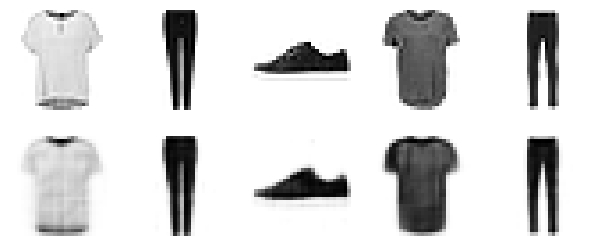

In [31]:
X_valid = fashion_valid_set[:10]
plot_reconstructions(sparse_ae, X_valid)
plt.show()

### Variational autoencoders

In [3]:
VAEOutput = namedtuple("VAEOutput", ['output', 'codings_mean', 'codings_logvar'])

class VAE(nn.Module):
    def __init__(self, codings_dim=32):
        super(VAE, self).__init__()
        self.codings_dim = codings_dim
        self.encoder = nn.Sequential(nn.Flatten(), nn.Linear(28*28, 128), nn.ReLU(),
                                     nn.Linear(128, 2*codings_dim))
        self.decoder = nn.Sequential(nn.Linear(codings_dim, 128), nn.ReLU(), 
                                     nn.Linear(128, 28*28), nn.Sigmoid(), nn.Unflatten(dim=1, unflattened_size=(1, 28, 28)))
        
    def encode(self, X):
        return self.encoder(X).chunk(2, dim=-1)
    
    def sample_codings(self, codings_mean, codings_logvar):
        codings_std = torch.exp(0.5*codings_logvar)
        noise = torch.randn_like(codings_std)
        return codings_mean + noise * codings_std
    
    def decode(self, X):
        return self.decoder(X)
    
    def forward(self, X):
        codings_mean, codings_logvar = self.encode(X)
        sampled_codings = self.sample_codings(codings_mean, codings_logvar)
        output = self.decode(sampled_codings)
        return VAEOutput(output, codings_mean, codings_logvar)
    
def vae_loss(y_pred, y_target, kl_weight=0.1):
    output, mean, logvar = y_pred
    kl_div = -0.5 * torch.sum(1+logvar-logvar.exp()-mean.square(), dim=-1)
    return F.mse_loss(output, y_target) + kl_weight * kl_div.mean() / 784

Epoch: 1/50	Train loss: 0.032	Train metrics: 0.167	Valid metrics: 0.140
Epoch: 2/50	Train loss: 0.022	Train metrics: 0.133	Valid metrics: 0.128
Epoch: 3/50	Train loss: 0.020	Train metrics: 0.124	Valid metrics: 0.123
Epoch: 4/50	Train loss: 0.018	Train metrics: 0.120	Valid metrics: 0.118
Epoch: 5/50	Train loss: 0.018	Train metrics: 0.116	Valid metrics: 0.116
Epoch: 6/50	Train loss: 0.017	Train metrics: 0.115	Valid metrics: 0.115
Epoch: 7/50	Train loss: 0.017	Train metrics: 0.115	Valid metrics: 0.115
Epoch: 8/50	Train loss: 0.017	Train metrics: 0.113	Valid metrics: 0.114
Epoch: 9/50	Train loss: 0.017	Train metrics: 0.113	Valid metrics: 0.113
Epoch: 10/50	Train loss: 0.017	Train metrics: 0.113	Valid metrics: 0.113
Epoch: 11/50	Train loss: 0.017	Train metrics: 0.112	Valid metrics: 0.113
Epoch: 12/50	Train loss: 0.017	Train metrics: 0.112	Valid metrics: 0.112
Epoch: 13/50	Train loss: 0.017	Train metrics: 0.112	Valid metrics: 0.112
Epoch: 14/50	Train loss: 0.017	Train metrics: 0.111	Valid me

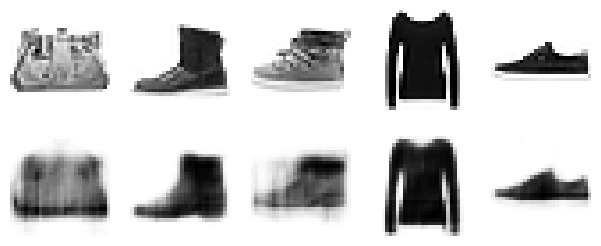

In [59]:
vae_model = VAE().to(device)
optimizer = torch.optim.NAdam(params=vae_model.parameters(), lr=0.001)
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)

history = train_model(vae_model, optimizer, vae_loss, rmse, fashion_train_loader, fashion_valid_loader, n_epochs=50)

X_valid = fashion_valid_set[:10]
plot_reconstructions(vae_model, X_valid)
plt.show()

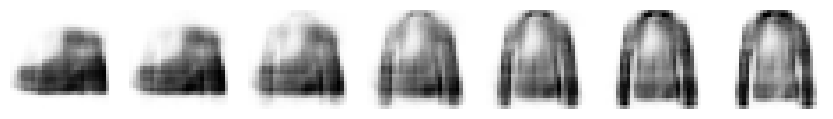

In [105]:
codings = torch.randn([2, vae_model.codings_dim])
weights = torch.linspace(0, 1, 7).view(7, 1)
codings = torch.lerp(codings[0], codings[1], weights)
with torch.no_grad():
    images = vae_model.decode(codings.to(device))
    
plot_reconstructions(vae_model, images, 7, True)

#### Discrete VAE

In [10]:
DVAEoutput = namedtuple('DVAEoutput', ['output', 'logits', 'codings_prob'])

class DVAEmodel(nn.Module):
    def __init__(self, coding_length=32, n_codes=16, temperature=1.0):
        super().__init__()
        self.coding_length = coding_length
        self.n_codes = n_codes
        self.temperature = temperature
        self.encoder = nn.Sequential(nn.Flatten(), nn.Linear(28*28, 256), nn.ReLU(),
                                     nn.Linear(256, 128), nn.ReLU(),
                                     nn.Linear(128, coding_length*n_codes),
                                     nn.Unflatten(dim=1, unflattened_size=(coding_length, n_codes)))
        
        self.decoder = nn.Sequential(nn.Flatten(), nn.Linear(coding_length*n_codes, 128), nn.ReLU(),
                                     nn.Linear(128, 256), nn.ReLU(), nn.Linear(256, 28*28), nn.Sigmoid(),
                                     nn.Unflatten(dim=1, unflattened_size=(1, 28, 28)))
        
    def forward(self, X):
        logits = self.encoder(X)
        probas = F.gumbel_softmax(logits, tau=self.temperature, hard=True)
        outputs = self.decoder(probas)
        return DVAEoutput(outputs, logits, probas)
    
    
def dvae_loss(y_pred, y_target, kl_weight=1):
    output, logits, _ = y_pred
    codings_probs = F.softmax(logits, -1)
    k = logits.new_tensor(logits.size(-1))
    kl_div = (codings_probs * (codings_probs.log() + k.log())).sum(dim=(1, 2))
    return F.mse_loss(output, y_target) + kl_weight * kl_div.mean() / 784

In [11]:
dvae_model = DVAEmodel().to(device)
nadam = torch.optim.NAdam(params=dvae_model.parameters())
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)

train_model(dvae_model, nadam, dvae_loss, rmse, fashion_train_loader, fashion_valid_loader, 50, temperature_decrease=True)

Epoch: 1/50	Train loss: 0.055	Train metrics: 0.221	Valid metrics: 0.199
Epoch: 2/50	Train loss: 0.045	Train metrics: 0.193	Valid metrics: 0.186
Epoch: 3/50	Train loss: 0.043	Train metrics: 0.186	Valid metrics: 0.184
Epoch: 4/50	Train loss: 0.041	Train metrics: 0.183	Valid metrics: 0.180
Epoch: 5/50	Train loss: 0.039	Train metrics: 0.179	Valid metrics: 0.178
Epoch: 6/50	Train loss: 0.039	Train metrics: 0.178	Valid metrics: 0.177
Epoch: 7/50	Train loss: 0.038	Train metrics: 0.177	Valid metrics: 0.175
Epoch: 8/50	Train loss: 0.037	Train metrics: 0.175	Valid metrics: 0.174
Epoch: 9/50	Train loss: 0.037	Train metrics: 0.174	Valid metrics: 0.173
Epoch: 10/50	Train loss: 0.037	Train metrics: 0.174	Valid metrics: 0.173
Epoch: 11/50	Train loss: 0.036	Train metrics: 0.173	Valid metrics: 0.171
Epoch: 12/50	Train loss: 0.036	Train metrics: 0.172	Valid metrics: 0.171
Epoch: 13/50	Train loss: 0.036	Train metrics: 0.172	Valid metrics: 0.170
Epoch: 14/50	Train loss: 0.036	Train metrics: 0.171	Valid me

{'train_loss': [0.055436848042453704,
  0.04533868059602638,
  0.04255727772590655,
  0.041026805018775335,
  0.039315860636137887,
  0.03864439188948615,
  0.038058960726869324,
  0.03717890645010552,
  0.03687225527944365,
  0.03665075362825234,
  0.036307147217003184,
  0.03603563992140805,
  0.036005233988217866,
  0.03564993932479131,
  0.03559934214156266,
  0.035534347649696194,
  0.0353871523204881,
  0.03536925919640023,
  0.035313114622491884,
  0.035241301304218105,
  0.035224195207843534,
  0.0351750203876942,
  0.03513382143574513,
  0.0351173326247407,
  0.03509432197358284,
  0.03506406936783684,
  0.03502742414660167,
  0.03502727100227967,
  0.03500916819787601,
  0.03511221801787355,
  0.035040523652084835,
  0.03502896379456227,
  0.03509480644986163,
  0.03501711291688483,
  0.0350391049178587,
  0.035093766915080433,
  0.03505318084923489,
  0.03502386831258569,
  0.03504246784620087,
  0.03499509646747437,
  0.035005033783367584,
  0.03505500908691811,
  0.0349634

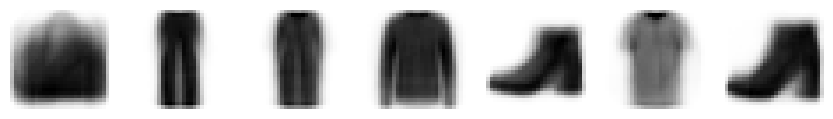

In [12]:
codings = torch.randint(0, dvae_model.n_codes, (7, dvae_model.coding_length), device=device)
codings_probs = F.one_hot(codings, num_classes=dvae_model.n_codes).float()
with torch.no_grad():
    images = dvae_model.decoder(codings_probs)
    
plot_reconstructions(dvae_model, images, 7, True)

# GANs

In [18]:
discriminator = nn.Sequential(nn.Flatten(), nn.Linear(28*28, 256), nn.ReLU(),
                              nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 1), nn.Sigmoid()).to(device)
codings_dim=32
generator = nn.Sequential(nn.Linear(codings_dim, 128), nn.ReLU(), nn.Linear(128, 256), nn.ReLU(),
                          nn.Linear(256, 28*28), nn.Sigmoid(), nn.Unflatten(dim=1, unflattened_size=(1, 28, 28))).to(device)

def train_gan(generator, discriminator, train_loader, codings_dim, n_epochs=20, g_lr=1e-3, d_lr=5e-4):
    criterion = nn.BCELoss()
    generator_optim = torch.optim.NAdam(generator.parameters(), lr=g_lr)
    discriminator_optim = torch.optim.NAdam(discriminator.parameters(), lr=d_lr)
    for epoch in range(n_epochs):
        d_total_loss = 0
        g_total_loss = 0
        for train_batch, _ in train_loader:
            train_batch = train_batch.to(device)
            pred_real = discriminator(train_batch)
            batch_size = pred_real.size(0)
            ones = torch.ones(batch_size, 1, device=device)
            real_loss = criterion(pred_real, ones)
            codings = torch.randn(batch_size, codings_dim, device=device)
            fake_images = generator(codings).detach()
            fake_pred = discriminator(fake_images)
            zeros = torch.zeros(batch_size, 1, device=device)
            fake_loss = criterion(fake_pred, zeros)
            discriminator_loss = real_loss + fake_loss
            d_total_loss += discriminator_loss.item()
            discriminator_optim.zero_grad()
            discriminator_loss.backward()
            discriminator_optim.step()
            
            codings = torch.randn(batch_size, codings_dim, device=device)
            generated_images = generator(codings)
            for p in discriminator.parameters():
                p.requires_grad = False
            fake_preds = discriminator(generated_images)
            g_loss = criterion(fake_preds, ones)
            g_total_loss += g_loss.item()
            generator_optim.zero_grad()
            g_loss.backward()
            generator_optim.step()
            for p in discriminator.parameters():
                p.requires_grad = True
        print(f"\rEpoch: {epoch}\tGenerator Loss: {g_total_loss/len(train_loader)}\tDiscriminator Loss: {d_total_loss/len(train_loader)}", end="")

In [19]:
train_gan(generator, discriminator, fashion_train_loader, 32, 20)

Epoch: 19	Generator Loss: 1.3449675521232	Discriminator Loss: 1.0616729089934998523

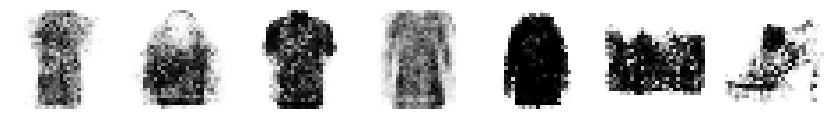

In [20]:
generator.eval()
codings = torch.randn(7, 32, device=device)
with torch.no_grad():
    images = generator(codings)
    
plot_reconstructions(generator, images, 7, True)

## Diffusion model

In [27]:
T=4000

def variance_schedule(T, s=0.008, max_beta=0.999):
    t = torch.linspace(0, T, T+1)
    f = torch.cos((t/T+s)/(1+s) * torch.pi/2)**2
    alpha_bars = f / f[0]
    betas = (1-f[1:]/f[:-1]).clamp(max=max_beta)
    betas = torch.cat([torch.zeros(1), betas])
    alphas = 1 - betas
    return alphas, betas, alpha_bars

alphas, betas, alpha_bars = variance_schedule(4000)

def forward_diffusion(x0, t):
    eps = torch.randn_like(x0)
    xt = alpha_bars[t].sqrt()*x0 + (1-alpha_bars[t]).sqrt() * eps
    return xt, eps

class DiffusionSample(namedtuple("DiffusionSampleBase", ['xt', 't'])):
    def to(self, device):
        return DiffusionSample(self.xt.to(device), self.t.to(device))
    
class DiffusionDataset:
    def __init__(self, dataset):
        self.dataset = dataset
        
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, i):
        x0, _ = self.dataset[i]
        x0 = (x0*2) - 1
        t = torch.randint(1, T+1, size=[1])
        xt, eps = forward_diffusion(x0, t)
        return DiffusionSample(xt, t), eps
    
diffusion_train_set = DiffusionDataset(fashion_train)
diffusion_train_loader = DataLoader(diffusion_train_set, batch_size=32, shuffle=True)

diffusion_valid_set = DiffusionDataset(fashion_valid)
diffsuion_valid_loader = DataLoader(diffusion_valid_set, batch_size=32) 

In [28]:
class TimeEncodings(nn.Module):
    def __init__(self, T, embed_dim):
        super().__init__()
        assert embed_dim % 2 == 0
        p = torch.arange(T+1).unsqueeze(1)
        angle = p / 10000 ** (torch.arange(0, embed_dim, 2) / embed_dim)
        te = torch.empty(T+1, embed_dim)
        te[:, 0::2] = torch.sin(angle)
        te[:, 1::2] = torch.cos(angle)
        self.register_buffer("time_encodings", te)
        
    def forward(self, t):
        return self.time_encodings[t]

In [34]:
class SeparableConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size, padding=padding, groups=in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        
    def forward(self, X):
        return self.pointwise(self.depthwise(X))
    
class DiffusionModel(nn.Module):
    def __init__(self, T=T, embed_dim=64):
        super().__init__()
        self.time_encodings = TimeEncodings(T, embed_dim)
        
        dim = 16
        self.pad = nn.ConstantPad2d((3, 3, 3, 3), 0)
        self.init_conv = nn.Conv2d(1, dim, kernel_size=3)
        self.init_bn = nn.BatchNorm2d(dim)
        self.time_adapter_init = nn.Linear(embed_dim, dim)
        
        #down
        self.down_blocks = nn.ModuleList()
        self.skip_convs = nn.ModuleList()
        self.time_adapters_down = nn.ModuleList()
        in_dim = dim
        for dim in (32, 64, 128):
            block = nn.Sequential(nn.ReLU(), SeparableConv2d(in_dim, dim, kernel_size=3, padding=1), nn.BatchNorm2d(dim),
                                  nn.ReLU(), SeparableConv2d(dim, dim, kernel_size=3, padding=1), nn.BatchNorm2d(dim))
            
            skip_conv = nn.Conv2d(in_dim, dim, kernel_size=1, stride=2)
            self.down_blocks.append(block)
            self.skip_convs.append(skip_conv)
            self.time_adapters_down.append(nn.Linear(embed_dim, dim))
            in_dim = dim
            
        #up
        self.up_blocks = nn.ModuleList()
        self.skip_up_convs = nn.ModuleList()
        self.time_adapters_up = nn.ModuleList()
        for dim in (64, 32, 16):
            block = nn.Sequential(nn.ReLU(), nn.ConvTranspose2d(in_dim, dim, kernel_size=3, padding=1), nn.BatchNorm2d(dim),
                                  nn.ReLU(), nn.ConvTranspose2d(dim, dim, kernel_size=3, padding=1), nn.BatchNorm2d(dim))
            skip_conv = nn.Conv2d(in_dim, dim, kernel_size=1)
            self.up_blocks.append(block)
            self.skip_up_convs.append(skip_conv)
            self.time_adapters_up.append(nn.Linear(embed_dim, dim))
            in_dim = dim * 3
            
        self.final_conv = nn.Conv2d(in_dim, 1, 3, padding=1)
        
    def forward(self, sample):
        if not isinstance(sample, DiffusionSample):
            print(repr(sample))
        time_enc = self.time_encodings(sample.t.squeeze(1))
        z = self.pad(sample.xt)
        z = F.relu(self.init_bn(self.init_conv(z)))
        z = z + self.time_adapter_init(time_enc)[:, :, None, None]
        skip = z
        cross_skips = []
        
        #Downsampling path
        for block, skip_conv, time_adapter in zip(self.down_blocks, self.skip_convs, self.time_adapters_down):
            z = block(z)
            cross_skips.append(z)
            z = F.max_pool2d(z, 3, stride=2, padding=1)
            skip_link = skip_conv(skip)
            z = z + skip_link
            z = z + time_adapter(time_enc)[:, :, None, None]
            skip = z
            
        #upsampling
        for block, skip_up_conv, time_adapter in zip(self.up_blocks, self.skip_up_convs, self.time_adapters_up):
            z = block(z)
            z = F.interpolate(z, scale_factor=2, mode="nearest")
            skip = F.interpolate(skip, scale_factor=2, mode="nearest")
            skip_link = skip_up_conv(skip)
            z = z + skip_link
            z = z + time_adapter(time_enc)[:, :, None, None]
            cross_skip = cross_skips.pop()
            z = torch.cat([z, cross_skip], dim=1)
            skip = z
            
            
        
        out = self.final_conv(z)
        out = out[:, :, 2:-2, 2:-2]
        return out.contiguous()

In [35]:
diffusion_model = DiffusionModel().to(device)

huber = nn.HuberLoss()
nadam = torch.optim.NAdam(diffusion_model.parameters(), lr=3e-3)
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)

history = train_model(diffusion_model, nadam, huber, rmse, diffusion_train_loader, diffsuion_valid_loader, 20)

Epoch: 1/20	Train loss: 0.065	Train metrics: 0.373	Valid metrics: 0.327
Epoch: 2/20	Train loss: 0.134	Train metrics: 1.772	Valid metrics: 0.320
Epoch: 3/20	Train loss: 0.046	Train metrics: 0.314	Valid metrics: 0.311
Epoch: 4/20	Train loss: 0.044	Train metrics: 0.307	Valid metrics: 0.303
Epoch: 5/20	Train loss: 0.042	Train metrics: 0.300	Valid metrics: 0.297
Epoch: 6/20	Train loss: 0.042	Train metrics: 0.298	Valid metrics: 0.295
Epoch: 7/20	Train loss: 0.042	Train metrics: 0.298	Valid metrics: 0.295
Epoch: 8/20	Train loss: 0.040	Train metrics: 0.294	Valid metrics: 0.293
Epoch: 9/20	Train loss: 0.040	Train metrics: 0.292	Valid metrics: 0.294
Epoch: 10/20	Train loss: 0.040	Train metrics: 0.294	Valid metrics: 0.291
Epoch: 11/20	Train loss: 0.040	Train metrics: 0.290	Valid metrics: 0.285
Epoch: 12/20	Train loss: 0.040	Train metrics: 0.291	Valid metrics: 0.294
Epoch: 13/20	Train loss: 0.039	Train metrics: 0.290	Valid metrics: 0.287
Epoch: 14/20	Train loss: 0.039	Train metrics: 0.290	Valid me

In [44]:
def generate_ddim(model, batch_size=32, num_steps=50, eta=0.85):
    model.eval()
    with torch.no_grad():
        xt = torch.randn([batch_size, 1, 28, 28], device=device)
        times = torch.linspace(T-1, 0, steps=num_steps+1).long().tolist()
        for t, t_prev in zip(times[:-1], times[1:]):
            t_batch = torch.full((batch_size, 1), t, device=device)
            sample = DiffusionSample(xt, t_batch)
            eps_pred = model(sample)
            x0 = ((xt - (1-alpha_bars[t]).sqrt() * eps_pred) / alpha_bars[t].sqrt())
            abar_t_prev = alpha_bars[t_prev]
            variance = eta * (1 - abar_t_prev) / (1 - alpha_bars[t]) * betas[t]
            sigma_t = variance.sqrt()
            pred_dir = (1 - abar_t_prev - sigma_t**2).sqrt() * eps_pred
            noise = torch.randn_like(xt)
            xt = abar_t_prev.sqrt() * x0 + pred_dir + sigma_t * noise
        
        return torch.clamp((xt + 1)/2, 0, 1)
    
X_gen_ddim = generate_ddim(diffusion_model, num_steps=500)

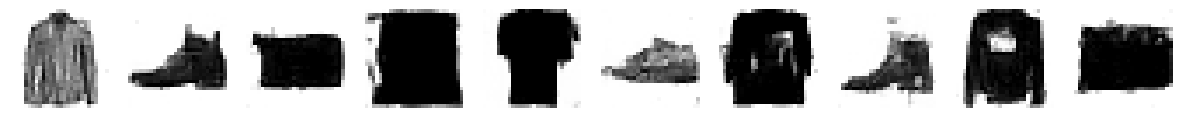

In [45]:
plot_reconstructions(diffusion_model, X_gen_ddim[:10], 7, True)

In [ ]:
pipe = AutoPipelineForText2Image.from_pretrained('stabilityai/sd-turbo', variant='fp16', dtype=torch.float16)
pipe.to(device)

/home/damian/New Folder/.venv/lib/python3.14/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Loading pipeline components...: 100%|██████████| 5/5 [00:00<00:00, 11.09it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 38.44it/s]


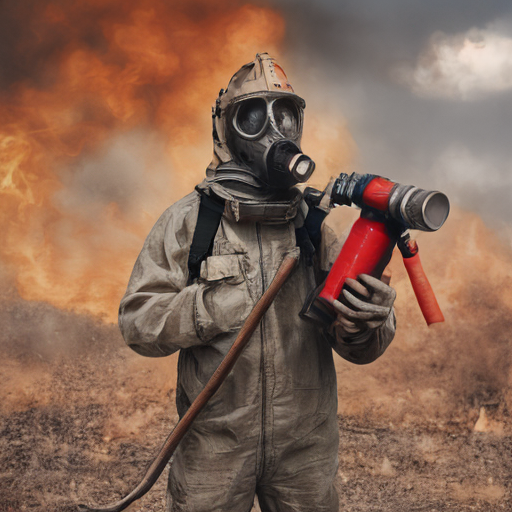

In [19]:
image = pipe(prompt='A man wearing a gas mask and holding a fire extinguisher', num_inference_steps=1, guidance_scale=0.0).images[0]
image